# V5 flow-proposal plots (per-rung experiment)

Side-by-side with [[flow-v4-plots-notebook]]. Sources:
* `flow_v5_results.pkl` &mdash; per-rung accept/IACT for all v5 runs (Tobs 6&ndash;12mo, default and `perrung_95_05`)
* `flow_v4_per_rung_metrics.pkl` &mdash; same fields re-extracted from the v4 backends so the comparison is apples-to-apples
* `flow_swap_statistics.pkl` &mdash; cumulative adjacent-rung swap acceptance for both versions
* `flow_6mo_v5_betas.npy` &mdash; the frozen ladder used at deployment

Each plot has its own STYLE dict at the top of its cell so you can tweak colors/markers/sizes without touching the plotting logic.

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import pickle
from pathlib import Path

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

if not hasattr(np, 'trapz'):
    np.trapz = np.trapezoid
if not hasattr(np, 'in1d'):
    np.in1d = np.isin

mpl.rcParams['font.family']       = 'STIXGeneral'
mpl.rcParams['mathtext.fontset']  = 'stix'
mpl.rcParams['mathtext.default']  = 'regular'
mpl.rcParams['axes.unicode_minus'] = False

In [2]:
RESULTS_DIR = Path('../data/flow_benchmark')
TOBS_MONTHS = [6, 7, 8, 9, 10, 11, 12]

with open(RESULTS_DIR / 'flow_v5_results.pkl', 'rb') as fh:
    v5 = pickle.load(fh)
with open(RESULTS_DIR / 'flow_v4_per_rung_metrics.pkl', 'rb') as fh:
    v4 = pickle.load(fh)
with open(RESULTS_DIR / 'flow_swap_statistics.pkl', 'rb') as fh:
    swap_stats = pickle.load(fh)
betas = np.load(RESULTS_DIR / 'flow_6mo_v5_betas.npy')
NTEMPS = len(betas)

print(f'Loaded {len(v5)} v5 runs, {len(v4)} v4 runs, {len(swap_stats)} swap entries.')
print(f'Frozen v5 ladder (ntemps={NTEMPS}):')
for k in range(NTEMPS):
    print(f'  k={k}  beta={betas[k]:.4e}')

Loaded 14 v5 runs, 16 v4 runs, 28 swap entries.
Frozen v5 ladder (ntemps=10):
  k=0  beta=1.0000e+00
  k=1  beta=3.5787e-01
  k=2  beta=1.3837e-01
  k=3  beta=5.7580e-02
  k=4  beta=2.6136e-02
  k=5  beta=1.1287e-02
  k=6  beta=4.0934e-03
  k=7  beta=1.2263e-03
  k=8  beta=3.7735e-04
  k=9  beta=1.2590e-04


## 1.  Per-rung acceptance vs $\beta$  (the headline plot)

Three panels at $T_\mathrm{obs} \in \{6, 9, 12\}$ mo. Each shows mean-walker acceptance at each rung, $\pm 1\sigma$ across the 24 walkers, for:
* StretchMove baseline (frozen ladder),
* v4 single-flow 95/5,
* v5 per-rung 95/5.

The v4 hot-rung collapse to &asymp;0 acceptance is the textbook **gotcha &#35;3** signature. v5's curve stays $\gtrsim 0.16$ at every rung at every Tobs.

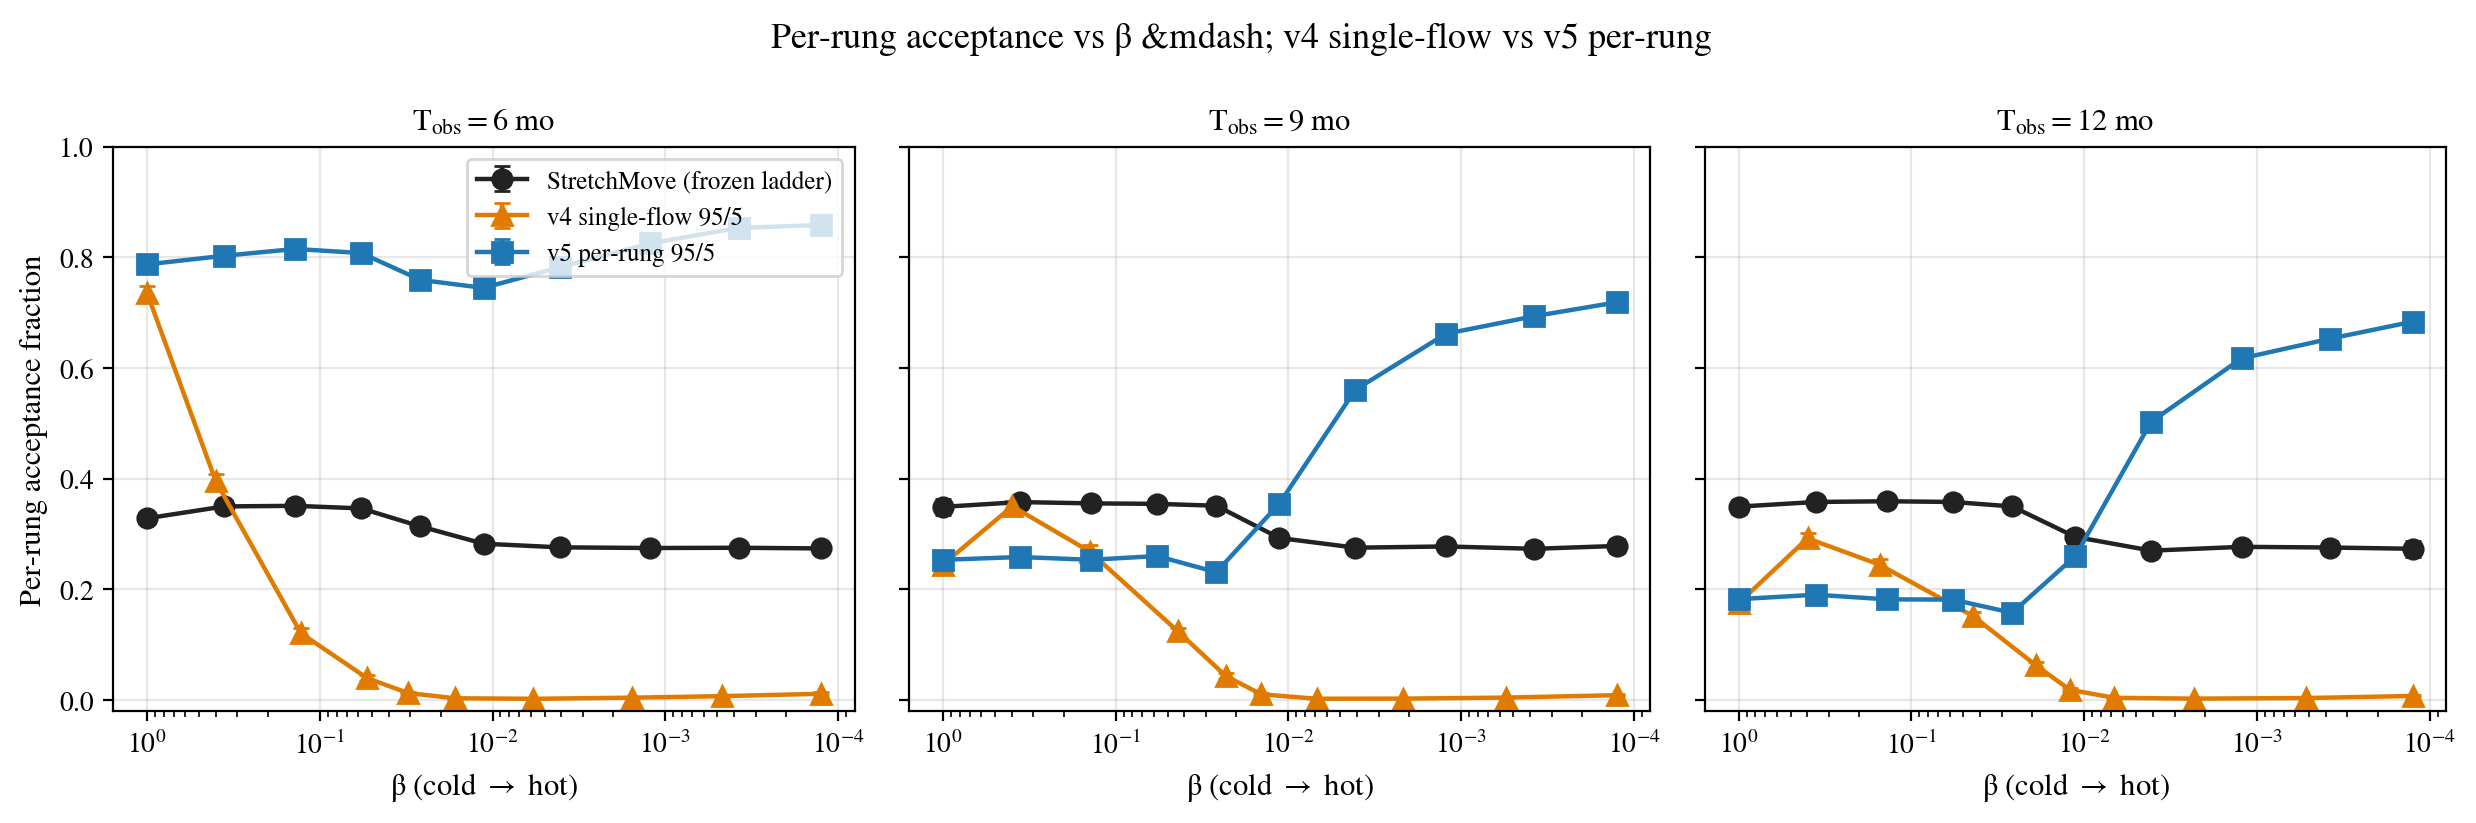

In [3]:
STYLE_ACC = {
    'stretch':  dict(color='#222222', marker='o', label='StretchMove (frozen ladder)'),
    'v4_flow':  dict(color='#E07B00', marker='^', label='v4 single-flow 95/5'),
    'v5_flow':  dict(color='#1F77B4', marker='s', label='v5 per-rung 95/5'),
    'panels_tobs': [6, 9, 12],
    'lw': 1.6, 'ms': 7, 'capsize': 3,
    'figsize': (12.5, 4.2),
    'grid_alpha': 0.3,
    'axis_fontsize': 11, 'tick_fontsize': 10, 'legend_fontsize': 9,
    'suptitle_fontsize': 13,
    'suptitle': r'Per-rung acceptance vs $\beta$ &mdash; v4 single-flow vs v5 per-rung',
    'xscale': 'log',
    'save_path': None,    # e.g. RESULTS_DIR / 'v5_per_rung_accept_vs_beta.png'
    'save_dpi': 160,
}

fig, axes = plt.subplots(1, 3, figsize=STYLE_ACC['figsize'], sharey=True)
for ax, m in zip(axes, STYLE_ACC['panels_tobs']):
    # v5 stretch baseline
    r = v5[f'v5_{m:02d}mo_default']
    af = r['accept_per_rung']
    ax.errorbar(betas, af.mean(axis=1), yerr=af.std(axis=1),
                fmt=f"-{STYLE_ACC['stretch']['marker']}", color=STYLE_ACC['stretch']['color'],
                lw=STYLE_ACC['lw'], ms=STYLE_ACC['ms'], capsize=STYLE_ACC['capsize'],
                label=STYLE_ACC['stretch']['label'])
    # v4 single-flow
    r = v4[f'v4_{m:02d}mo_flow_full_95_05']
    af4 = r['accept_per_rung']
    # v4 betas (adaptive) -- use beta_final stored in the metrics dict
    b4 = r['beta_final']
    ax.errorbar(b4, af4.mean(axis=1), yerr=af4.std(axis=1),
                fmt=f"-{STYLE_ACC['v4_flow']['marker']}", color=STYLE_ACC['v4_flow']['color'],
                lw=STYLE_ACC['lw'], ms=STYLE_ACC['ms'], capsize=STYLE_ACC['capsize'],
                label=STYLE_ACC['v4_flow']['label'])
    # v5 per-rung
    r = v5[f'v5_{m:02d}mo_perrung_95_05']
    af5 = r['accept_per_rung']
    ax.errorbar(betas, af5.mean(axis=1), yerr=af5.std(axis=1),
                fmt=f"-{STYLE_ACC['v5_flow']['marker']}", color=STYLE_ACC['v5_flow']['color'],
                lw=STYLE_ACC['lw'], ms=STYLE_ACC['ms'], capsize=STYLE_ACC['capsize'],
                label=STYLE_ACC['v5_flow']['label'])
    ax.set_xscale(STYLE_ACC['xscale'])
    ax.invert_xaxis()
    ax.set_xlabel(r'$\beta$ (cold $\rightarrow$ hot)', fontsize=STYLE_ACC['axis_fontsize'])
    ax.set_title(rf'$T_\mathrm{{obs}} = {m}$ mo', fontsize=STYLE_ACC['axis_fontsize'])
    ax.set_ylim(-0.02, 1.0)
    ax.grid(alpha=STYLE_ACC['grid_alpha'])
    ax.tick_params(labelsize=STYLE_ACC['tick_fontsize'])
axes[0].set_ylabel('Per-rung acceptance fraction', fontsize=STYLE_ACC['axis_fontsize'])
axes[0].legend(fontsize=STYLE_ACC['legend_fontsize'], loc='upper right')
fig.suptitle(STYLE_ACC['suptitle'], fontsize=STYLE_ACC['suptitle_fontsize'])
fig.tight_layout()
if STYLE_ACC['save_path']:
    fig.savefig(STYLE_ACC['save_path'], dpi=STYLE_ACC['save_dpi'])
    print(f"saved {STYLE_ACC['save_path']}")
plt.show()

## 2.  Per-rung IACT vs $\beta$

The IACT story is more nuanced than acceptance suggests. v4's *very* hot rung ($\beta \sim 10^{-4}$) has IACT 20&ndash;35 because the chain barely moves under its own proposals. v5 brings it down to $\lesssim 2$. At the cold rung the two are tied at every Tobs &mdash; per-rung dispatch does not improve cold-chain mixing in this single-mode posterior.

Note the log y-axis.

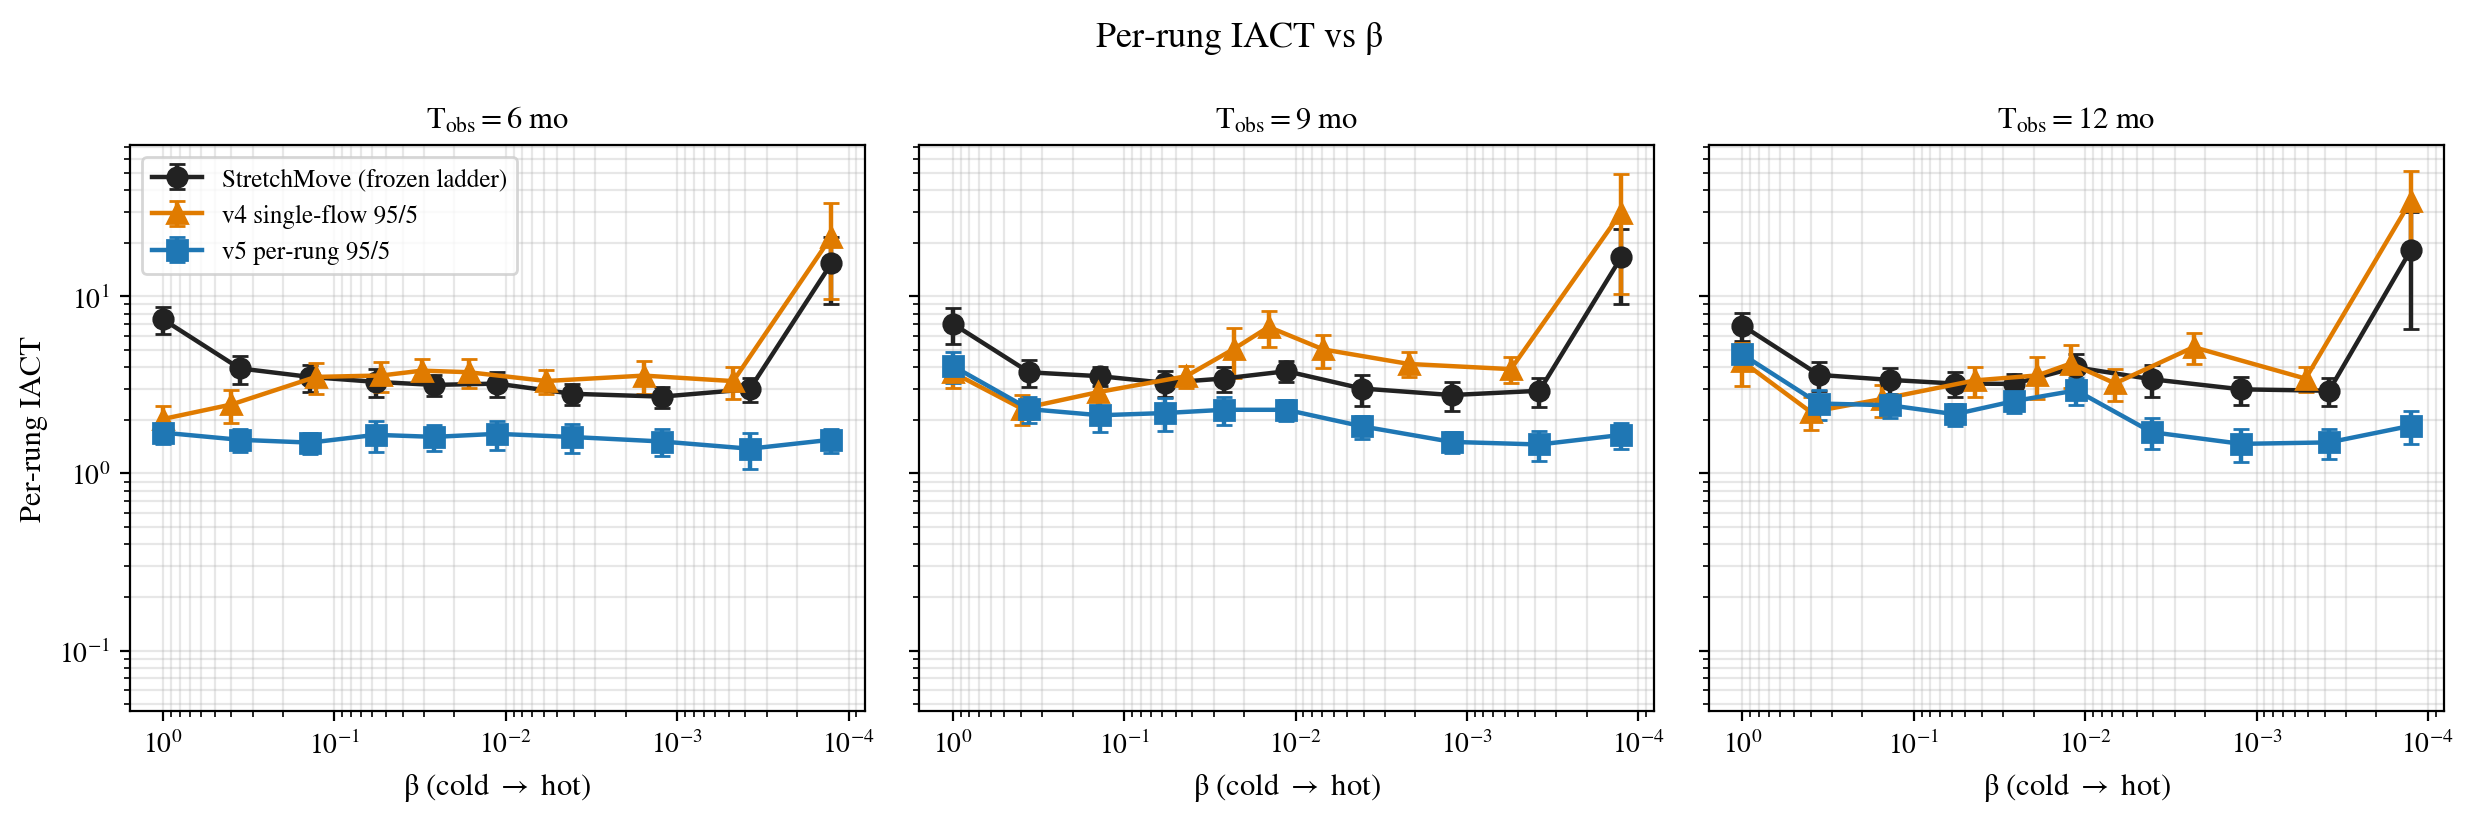

In [4]:
STYLE_IACT = {
    'stretch':  dict(color='#222222', marker='o', label='StretchMove (frozen ladder)'),
    'v4_flow':  dict(color='#E07B00', marker='^', label='v4 single-flow 95/5'),
    'v5_flow':  dict(color='#1F77B4', marker='s', label='v5 per-rung 95/5'),
    'panels_tobs': [6, 9, 12],
    'lw': 1.6, 'ms': 7, 'capsize': 3,
    'figsize': (12.5, 4.2),
    'grid_alpha': 0.3,
    'axis_fontsize': 11, 'tick_fontsize': 10, 'legend_fontsize': 9,
    'suptitle_fontsize': 13,
    'suptitle': r'Per-rung IACT vs $\beta$',
    'yscale': 'log',
    'save_path': None,
    'save_dpi': 160,
}

fig, axes = plt.subplots(1, 3, figsize=STYLE_IACT['figsize'], sharey=True)
for ax, m in zip(axes, STYLE_IACT['panels_tobs']):
    r = v5[f'v5_{m:02d}mo_default']
    it = r['iact_per_rung']
    ax.errorbar(betas, it.mean(axis=1), yerr=it.std(axis=1),
                fmt=f"-{STYLE_IACT['stretch']['marker']}", color=STYLE_IACT['stretch']['color'],
                lw=STYLE_IACT['lw'], ms=STYLE_IACT['ms'], capsize=STYLE_IACT['capsize'],
                label=STYLE_IACT['stretch']['label'])
    r = v4[f'v4_{m:02d}mo_flow_full_95_05']
    it4 = r['iact_per_rung']
    b4 = r['beta_final']
    ax.errorbar(b4, it4.mean(axis=1), yerr=it4.std(axis=1),
                fmt=f"-{STYLE_IACT['v4_flow']['marker']}", color=STYLE_IACT['v4_flow']['color'],
                lw=STYLE_IACT['lw'], ms=STYLE_IACT['ms'], capsize=STYLE_IACT['capsize'],
                label=STYLE_IACT['v4_flow']['label'])
    r = v5[f'v5_{m:02d}mo_perrung_95_05']
    it5 = r['iact_per_rung']
    ax.errorbar(betas, it5.mean(axis=1), yerr=it5.std(axis=1),
                fmt=f"-{STYLE_IACT['v5_flow']['marker']}", color=STYLE_IACT['v5_flow']['color'],
                lw=STYLE_IACT['lw'], ms=STYLE_IACT['ms'], capsize=STYLE_IACT['capsize'],
                label=STYLE_IACT['v5_flow']['label'])
    ax.set_xscale('log')
    ax.invert_xaxis()
    ax.set_yscale(STYLE_IACT['yscale'])
    ax.set_xlabel(r'$\beta$ (cold $\rightarrow$ hot)', fontsize=STYLE_IACT['axis_fontsize'])
    ax.set_title(rf'$T_\mathrm{{obs}} = {m}$ mo', fontsize=STYLE_IACT['axis_fontsize'])
    ax.grid(alpha=STYLE_IACT['grid_alpha'], which='both')
    ax.tick_params(labelsize=STYLE_IACT['tick_fontsize'])
axes[0].set_ylabel('Per-rung IACT', fontsize=STYLE_IACT['axis_fontsize'])
axes[0].legend(fontsize=STYLE_IACT['legend_fontsize'], loc='upper left')
fig.suptitle(STYLE_IACT['suptitle'], fontsize=STYLE_IACT['suptitle_fontsize'])
fig.tight_layout()
if STYLE_IACT['save_path']:
    fig.savefig(STYLE_IACT['save_path'], dpi=STYLE_IACT['save_dpi'])
    print(f"saved {STYLE_IACT['save_path']}")
plt.show()

## 3.  Cold-chain metrics vs $T_\mathrm{obs}$

Mirror of the v4 4-panel plot, but now overlaying v4 single-flow and v5 per-rung on the same axes. The lines lie nearly on top of each other for cold acceptance, cold IACT, and ESS/N. v5's per-rung dispatch has higher per-step overhead, so it loses ~10&ndash;25% on ESS/sec at $T_\mathrm{obs} > 6$ mo.

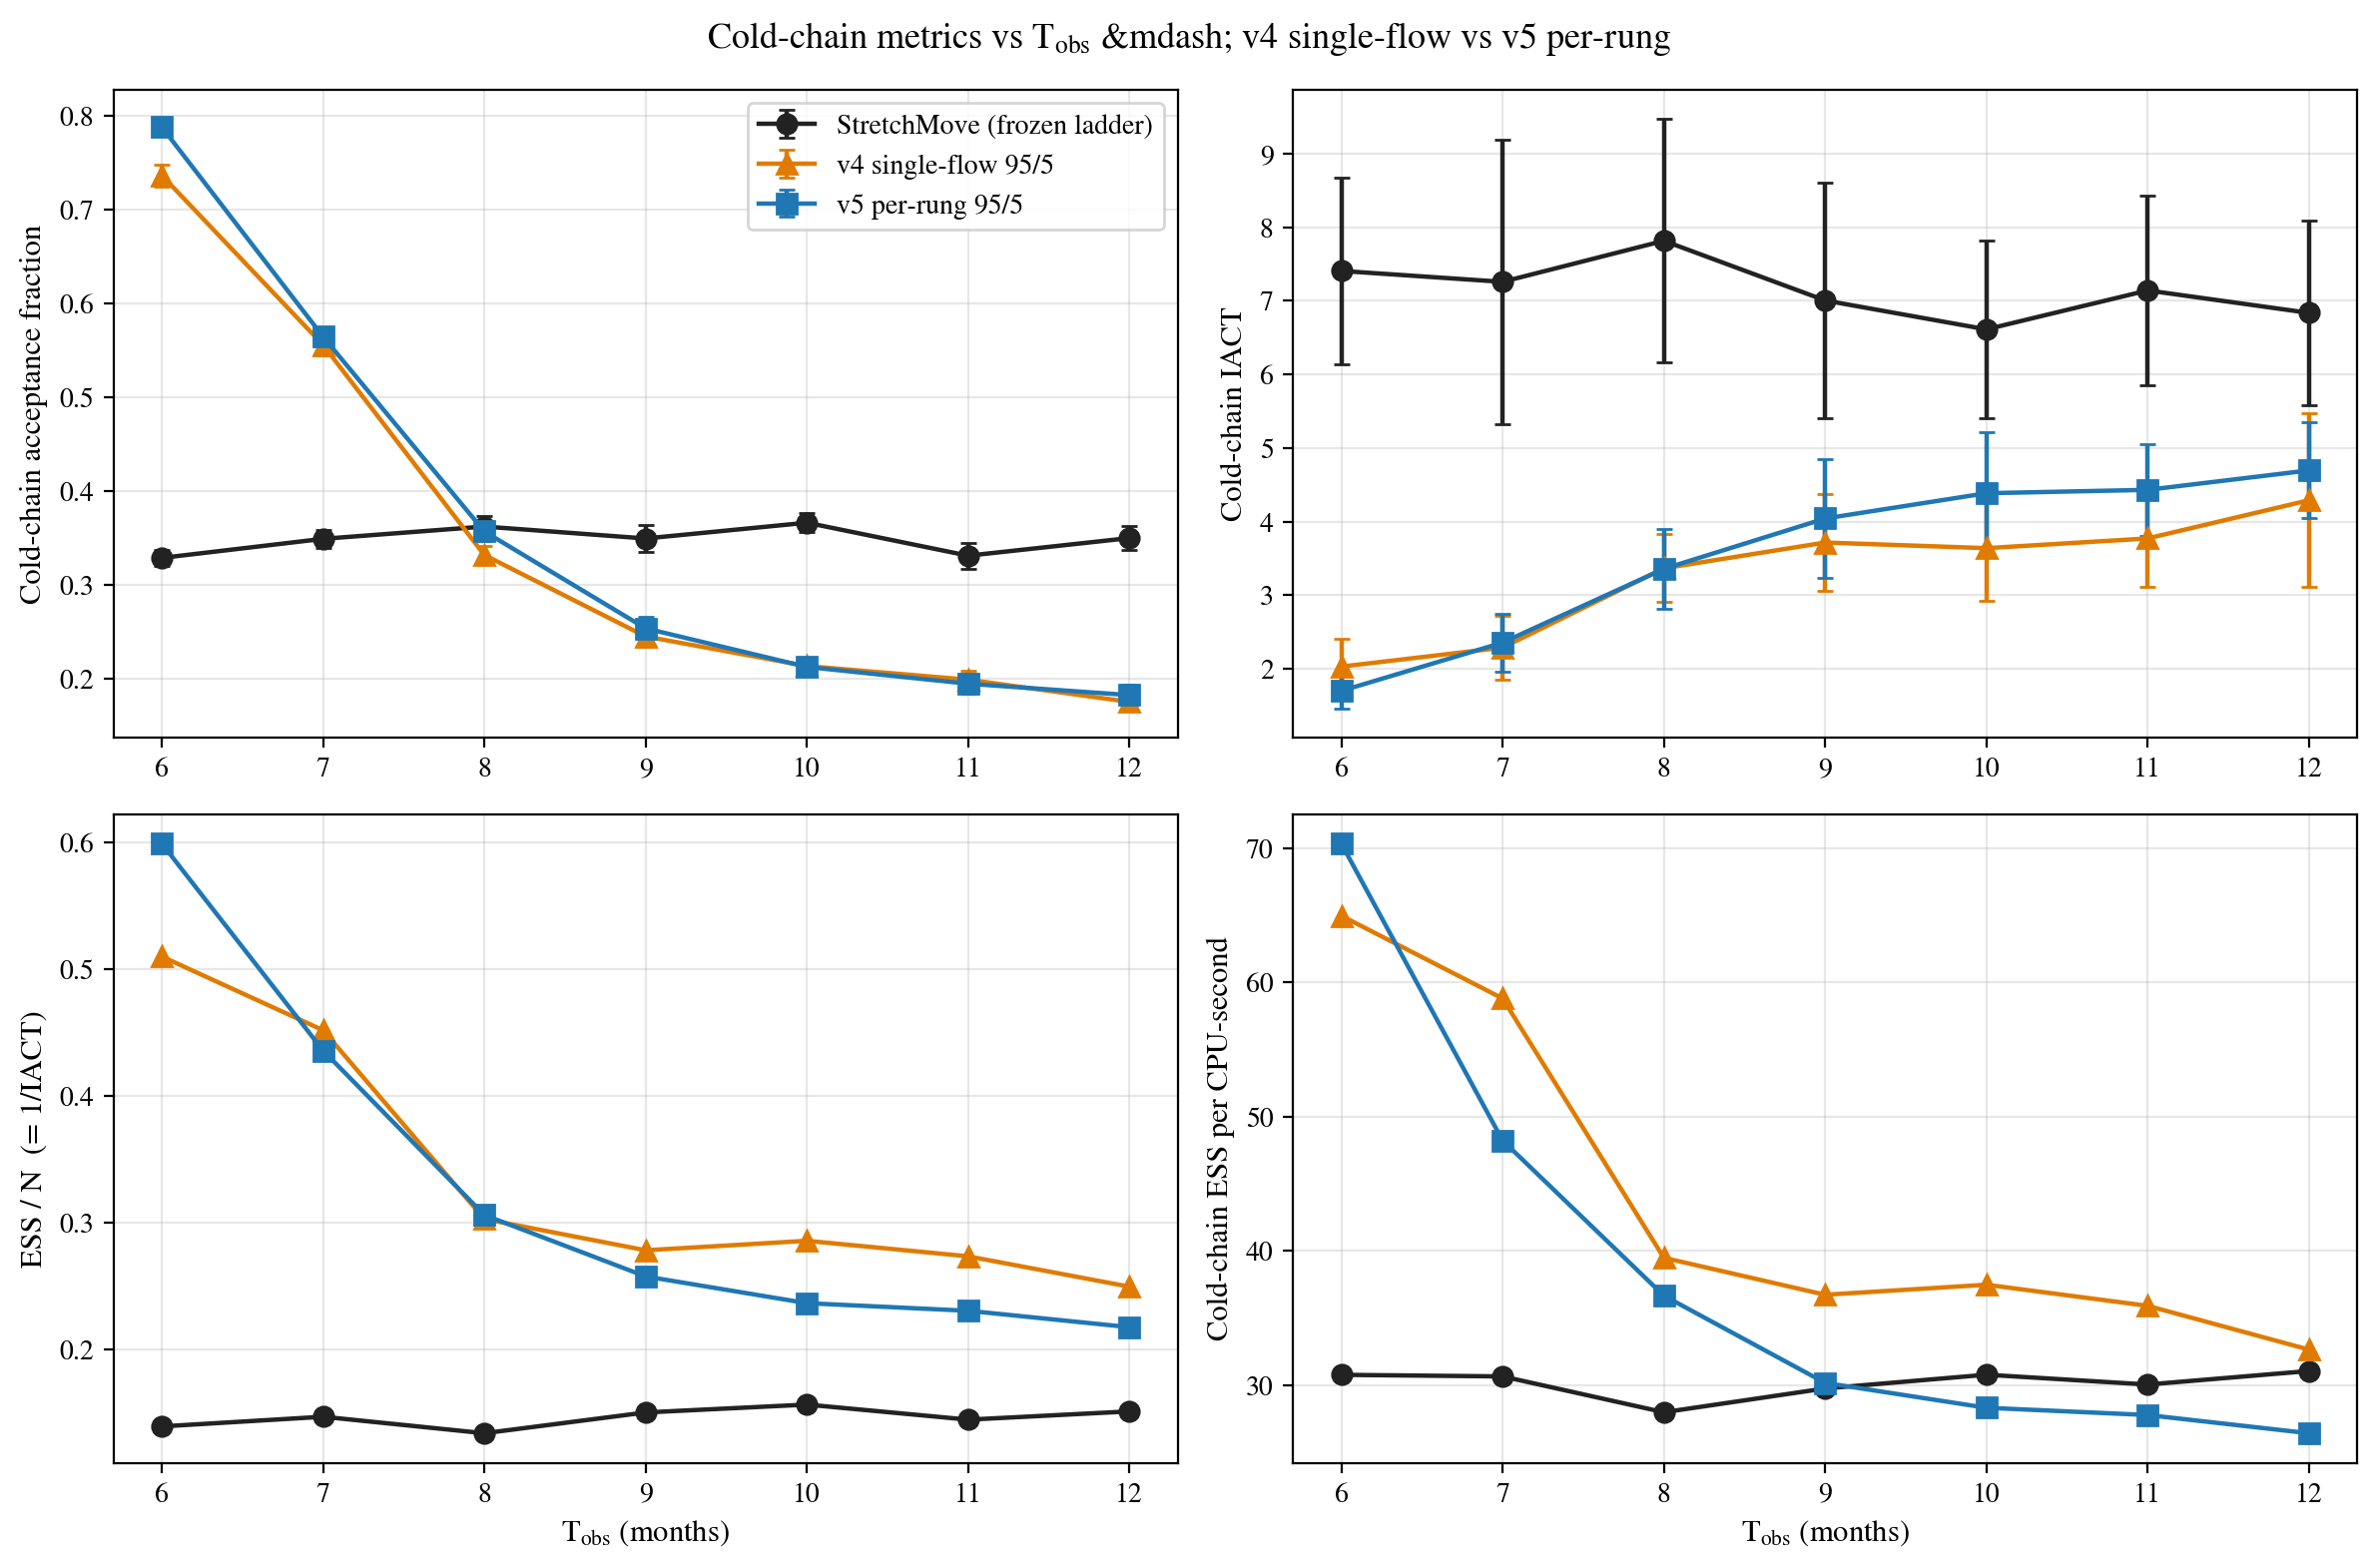

In [5]:
STYLE_TOBS = {
    'stretch':  dict(color='#222222', marker='o', label='StretchMove (frozen ladder)'),
    'v4_flow':  dict(color='#E07B00', marker='^', label='v4 single-flow 95/5'),
    'v5_flow':  dict(color='#1F77B4', marker='s', label='v5 per-rung 95/5'),
    'lw': 1.6, 'ms': 7, 'capsize': 3,
    'figsize': (12, 8),
    'grid_alpha': 0.3,
    'axis_fontsize': 11, 'tick_fontsize': 10, 'legend_fontsize': 10,
    'suptitle_fontsize': 13,
    'suptitle': r'Cold-chain metrics vs $T_\mathrm{obs}$ &mdash; v4 single-flow vs v5 per-rung',
    'panel_titles': {
        'acc':  'Cold-chain acceptance fraction',
        'iact': 'Cold-chain IACT',
        'ess_n':'ESS / N  (= 1/IACT)',
        'ess_s':'Cold-chain ESS per CPU-second',
    },
    'save_path': None,
    'save_dpi': 160,
}

def v5_series(key_template):
    o = {k: [] for k in ['acc_mean','acc_std','iact_mean','iact_std','ess_n','ess_s']}
    for m in TOBS_MONTHS:
        r = v5[key_template.format(m=m)]
        af = r['accept_per_rung'][0]
        it = r['iact_per_rung'][0]
        o['acc_mean'].append(af.mean()); o['acc_std'].append(af.std())
        o['iact_mean'].append(it.mean()); o['iact_std'].append(it.std())
        o['ess_n'].append((1.0/it).mean()); o['ess_s'].append(r['ess_per_sec_cold'])
    return {k: np.asarray(v) for k, v in o.items()}

def v4_series(key_template):
    # v4 stored cold-only ESS/sec in flow_v4_results.pkl; load it separately
    with open(RESULTS_DIR / 'flow_v4_results.pkl', 'rb') as fh:
        v4_cold = pickle.load(fh)
    o = {k: [] for k in ['acc_mean','acc_std','iact_mean','iact_std','ess_n','ess_s']}
    for m in TOBS_MONTHS:
        r = v4_cold[key_template.format(m=m)]
        o['acc_mean'].append(r['accept_cold'].mean()); o['acc_std'].append(r['accept_cold'].std())
        o['iact_mean'].append(r['iact_cold'].mean()); o['iact_std'].append(r['iact_cold'].std())
        o['ess_n'].append(r['ess_per_n'].mean()); o['ess_s'].append(r['ess_per_sec'])
    return {k: np.asarray(v) for k, v in o.items()}

s_stretch = v5_series('v5_{m:02d}mo_default')
s_v4flow  = v4_series('v4_{m:02d}mo_flow_full_95_05')
s_v5flow  = v5_series('v5_{m:02d}mo_perrung_95_05')
months    = np.array(TOBS_MONTHS, dtype=float)

fig, axes = plt.subplots(2, 2, figsize=STYLE_TOBS['figsize'])
panels = [
    (axes[0, 0], STYLE_TOBS['panel_titles']['acc'],   'acc_mean',  'acc_std'),
    (axes[0, 1], STYLE_TOBS['panel_titles']['iact'],  'iact_mean', 'iact_std'),
    (axes[1, 0], STYLE_TOBS['panel_titles']['ess_n'], 'ess_n',     None),
    (axes[1, 1], STYLE_TOBS['panel_titles']['ess_s'], 'ess_s',     None),
]
for ii, (ax, title, k_mean, k_std) in enumerate(panels):
    for series_key, s in [('stretch', s_stretch), ('v4_flow', s_v4flow), ('v5_flow', s_v5flow)]:
        st = STYLE_TOBS[series_key]
        if k_std is not None:
            ax.errorbar(months, s[k_mean], yerr=s[k_std],
                        fmt=f"-{st['marker']}", color=st['color'],
                        capsize=STYLE_TOBS['capsize'], lw=STYLE_TOBS['lw'],
                        ms=STYLE_TOBS['ms'], label=st['label'])
        else:
            ax.plot(months, s[k_mean], f"-{st['marker']}",
                    color=st['color'], lw=STYLE_TOBS['lw'], ms=STYLE_TOBS['ms'],
                    label=st['label'])
    if ii in [2, 3]:
        ax.set_xlabel(r'$T_\mathrm{obs}$ (months)', fontsize=STYLE_TOBS['axis_fontsize'])
    ax.set_ylabel(title, fontsize=STYLE_TOBS['axis_fontsize'])
    ax.set_xticks(TOBS_MONTHS)
    ax.tick_params(labelsize=STYLE_TOBS['tick_fontsize'])
    ax.grid(alpha=STYLE_TOBS['grid_alpha'])
    if ii == 0:
        ax.legend(fontsize=STYLE_TOBS['legend_fontsize'])
fig.suptitle(STYLE_TOBS['suptitle'], fontsize=STYLE_TOBS['suptitle_fontsize'])
fig.tight_layout()
if STYLE_TOBS['save_path']:
    fig.savefig(STYLE_TOBS['save_path'], dpi=STYLE_TOBS['save_dpi'])
    print(f"saved {STYLE_TOBS['save_path']}")
plt.show()

## 4.  PT swap acceptance per adjacent rung pair

Surprise of this experiment: PT swap acceptance is *essentially identical* between v4 and v5 at every $T_\mathrm{obs}$. Swap acceptance is set by ladder geometry, not by within-rung proposal quality &mdash; so per-rung dispatch can't help here. Mean swap acceptance hovers around 0.48&ndash;0.52 throughout.

Two presentations: (a) per-pair lines at each $T_\mathrm{obs}$, (b) mean over pairs as a function of $T_\mathrm{obs}$.

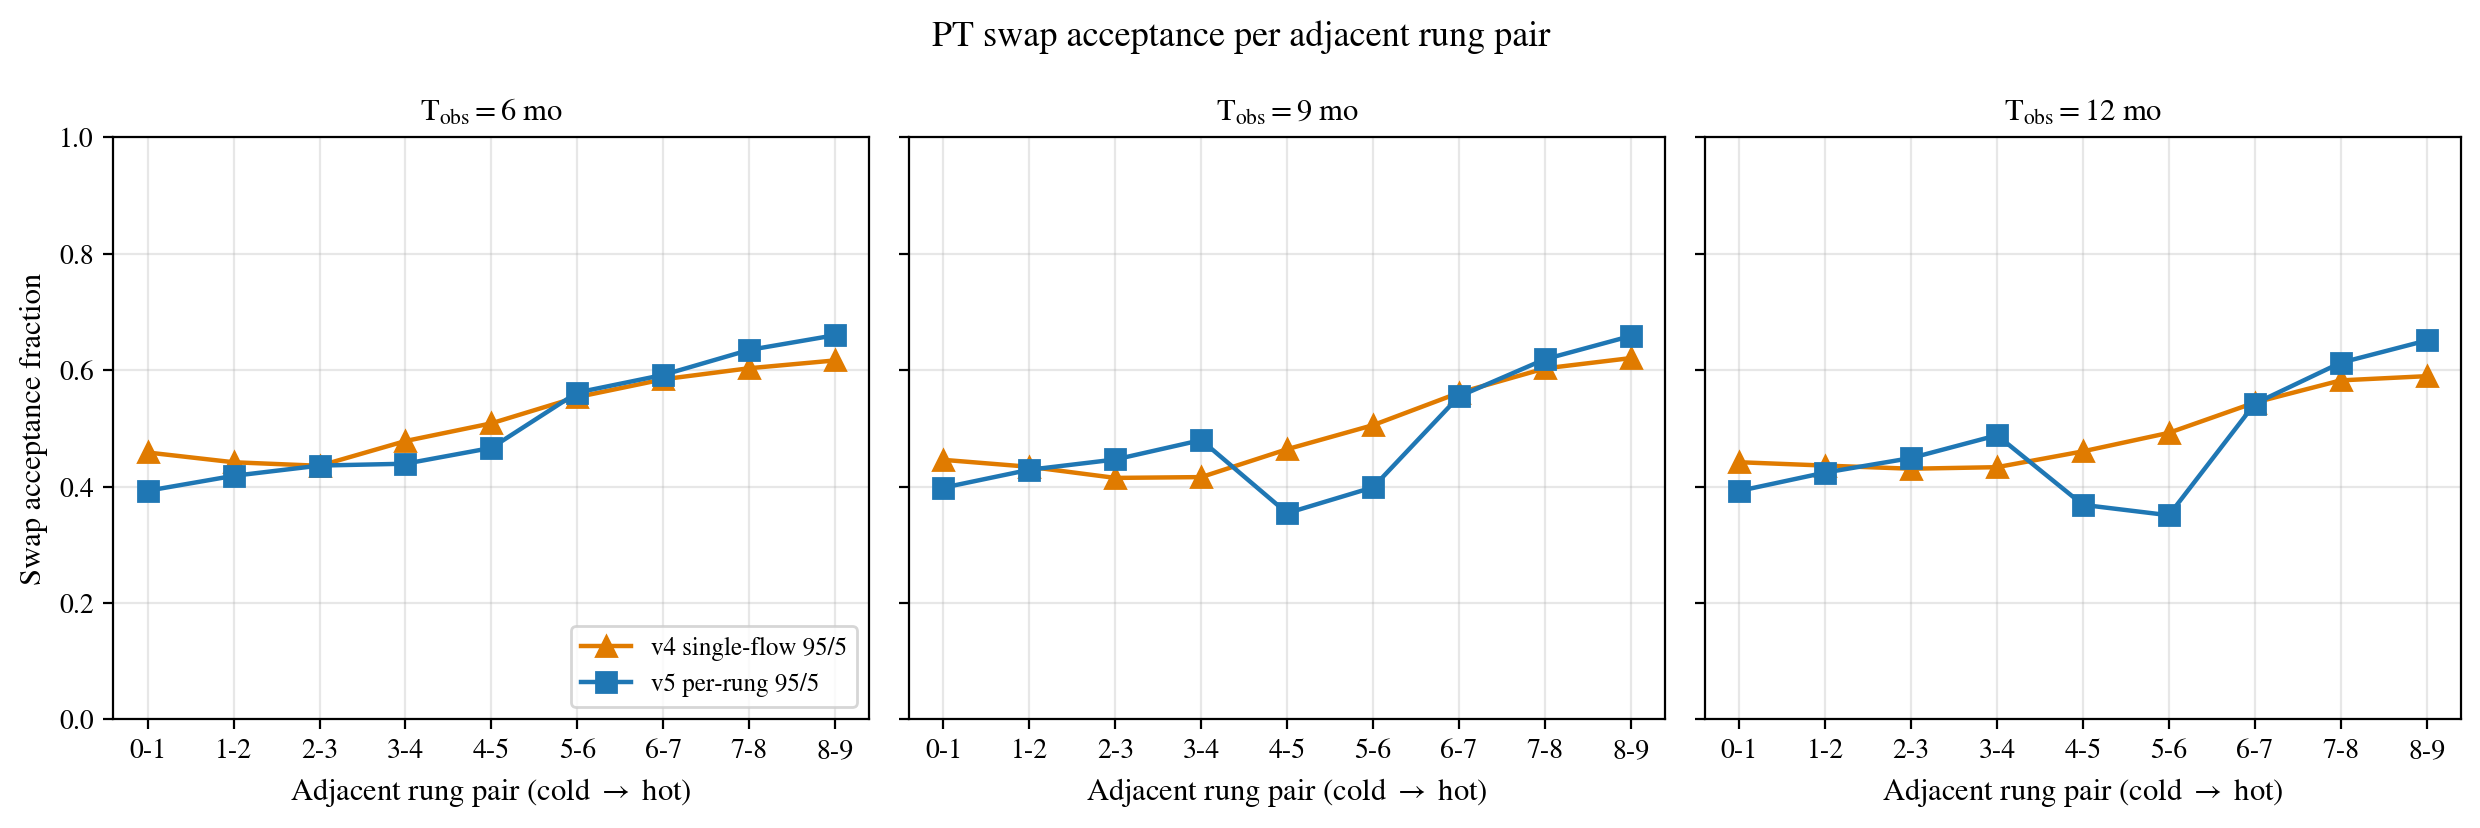

In [6]:
STYLE_SWAP = {
    'v4_flow':  dict(color='#E07B00', marker='^', label='v4 single-flow 95/5'),
    'v5_flow':  dict(color='#1F77B4', marker='s', label='v5 per-rung 95/5'),
    'panels_tobs': [6, 9, 12],
    'lw': 1.6, 'ms': 7, 'figsize': (12.5, 4.2),
    'grid_alpha': 0.3,
    'axis_fontsize': 11, 'tick_fontsize': 10, 'legend_fontsize': 9,
    'suptitle_fontsize': 13,
    'suptitle': 'PT swap acceptance per adjacent rung pair',
    'save_path': None, 'save_dpi': 160,
}

fig, axes = plt.subplots(1, 3, figsize=STYLE_SWAP['figsize'], sharey=True)
for ax, m in zip(axes, STYLE_SWAP['panels_tobs']):
    s4 = swap_stats[f'v4_{m:02d}mo_flow_full_95_05']['swap_accept']
    s5 = swap_stats[f'v5_{m:02d}mo_perrung_95_05']['swap_accept']
    pair_idx = np.arange(len(s4))
    ax.plot(pair_idx, s4, f"-{STYLE_SWAP['v4_flow']['marker']}",
            color=STYLE_SWAP['v4_flow']['color'], lw=STYLE_SWAP['lw'], ms=STYLE_SWAP['ms'],
            label=STYLE_SWAP['v4_flow']['label'])
    ax.plot(pair_idx, s5, f"-{STYLE_SWAP['v5_flow']['marker']}",
            color=STYLE_SWAP['v5_flow']['color'], lw=STYLE_SWAP['lw'], ms=STYLE_SWAP['ms'],
            label=STYLE_SWAP['v5_flow']['label'])
    ax.set_xticks(pair_idx)
    ax.set_xticklabels([f'{i}-{i+1}' for i in pair_idx], fontsize=STYLE_SWAP['tick_fontsize'])
    ax.set_xlabel('Adjacent rung pair (cold $\\rightarrow$ hot)',
                  fontsize=STYLE_SWAP['axis_fontsize'])
    ax.set_title(rf'$T_\mathrm{{obs}} = {m}$ mo', fontsize=STYLE_SWAP['axis_fontsize'])
    ax.set_ylim(0.0, 1.0)
    ax.grid(alpha=STYLE_SWAP['grid_alpha'])
axes[0].set_ylabel('Swap acceptance fraction', fontsize=STYLE_SWAP['axis_fontsize'])
axes[0].legend(fontsize=STYLE_SWAP['legend_fontsize'], loc='lower right')
fig.suptitle(STYLE_SWAP['suptitle'], fontsize=STYLE_SWAP['suptitle_fontsize'])
fig.tight_layout()
if STYLE_SWAP['save_path']:
    fig.savefig(STYLE_SWAP['save_path'], dpi=STYLE_SWAP['save_dpi'])
    print(f"saved {STYLE_SWAP['save_path']}")
plt.show()

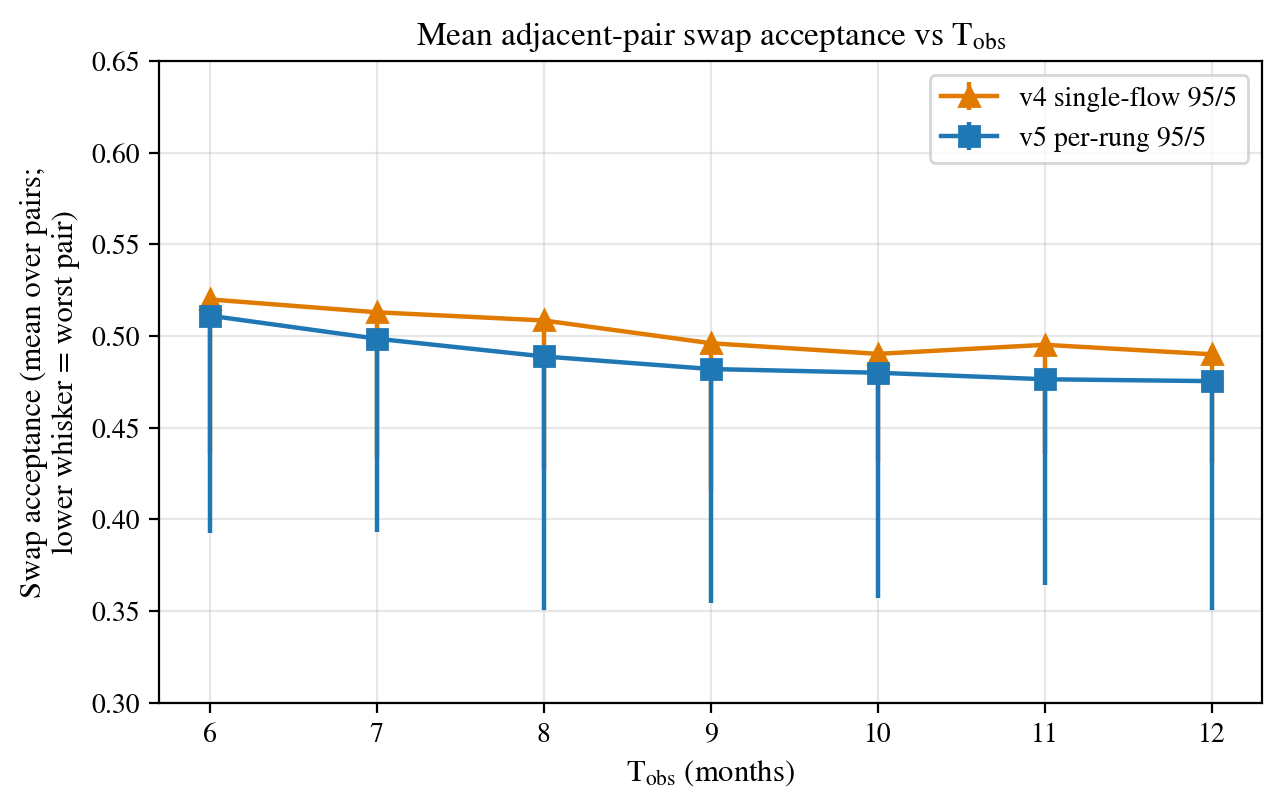

In [7]:
STYLE_SWAP_TOBS = {
    'v4_flow':  dict(color='#E07B00', marker='^', label='v4 single-flow 95/5'),
    'v5_flow':  dict(color='#1F77B4', marker='s', label='v5 per-rung 95/5'),
    'lw': 1.6, 'ms': 7, 'capsize': 3,
    'figsize': (6.5, 4.2),
    'grid_alpha': 0.3,
    'axis_fontsize': 11, 'tick_fontsize': 10, 'legend_fontsize': 10,
    'title_fontsize': 12,
    'title': 'Mean adjacent-pair swap acceptance vs $T_\\mathrm{obs}$',
    'save_path': None, 'save_dpi': 160,
}

months = np.array(TOBS_MONTHS, dtype=float)
mean_v4, min_v4 = [], []
mean_v5, min_v5 = [], []
for m in TOBS_MONTHS:
    s4 = swap_stats[f'v4_{m:02d}mo_flow_full_95_05']['swap_accept']
    s5 = swap_stats[f'v5_{m:02d}mo_perrung_95_05']['swap_accept']
    mean_v4.append(s4.mean()); min_v4.append(s4.min())
    mean_v5.append(s5.mean()); min_v5.append(s5.min())

fig, ax = plt.subplots(figsize=STYLE_SWAP_TOBS['figsize'])
ax.errorbar(months, mean_v4, yerr=[np.array(mean_v4)-np.array(min_v4), np.zeros_like(mean_v4)],
            fmt=f"-{STYLE_SWAP_TOBS['v4_flow']['marker']}", color=STYLE_SWAP_TOBS['v4_flow']['color'],
            lw=STYLE_SWAP_TOBS['lw'], ms=STYLE_SWAP_TOBS['ms'],
            label=STYLE_SWAP_TOBS['v4_flow']['label'])
ax.errorbar(months, mean_v5, yerr=[np.array(mean_v5)-np.array(min_v5), np.zeros_like(mean_v5)],
            fmt=f"-{STYLE_SWAP_TOBS['v5_flow']['marker']}", color=STYLE_SWAP_TOBS['v5_flow']['color'],
            lw=STYLE_SWAP_TOBS['lw'], ms=STYLE_SWAP_TOBS['ms'],
            label=STYLE_SWAP_TOBS['v5_flow']['label'])
ax.set_xticks(TOBS_MONTHS)
ax.set_xlabel(r'$T_\mathrm{obs}$ (months)', fontsize=STYLE_SWAP_TOBS['axis_fontsize'])
ax.set_ylabel('Swap acceptance (mean over pairs;\nlower whisker = worst pair)',
              fontsize=STYLE_SWAP_TOBS['axis_fontsize'])
ax.set_ylim(0.30, 0.65)
ax.grid(alpha=STYLE_SWAP_TOBS['grid_alpha'])
ax.legend(fontsize=STYLE_SWAP_TOBS['legend_fontsize'])
ax.set_title(STYLE_SWAP_TOBS['title'], fontsize=STYLE_SWAP_TOBS['title_fontsize'])
fig.tight_layout()
if STYLE_SWAP_TOBS['save_path']:
    fig.savefig(STYLE_SWAP_TOBS['save_path'], dpi=STYLE_SWAP_TOBS['save_dpi'])
    print(f"saved {STYLE_SWAP_TOBS['save_path']}")
plt.show()

## 5.  Numeric summary table

In [8]:
print('=== Head-to-head: v4 single-flow vs v5 per-rung (cold + min-rung + mean swap) ===')
print(f'{"Tobs":<5} {"v4 cold acc / IACT / ESS/sec / min-rung acc / swap_mean":>58}'
      f' | {"v5 cold acc / IACT / ESS/sec / min-rung acc / swap_mean":>58}')
for m in TOBS_MONTHS:
    r4 = v4[f'v4_{m:02d}mo_flow_full_95_05']
    r5 = v5[f'v5_{m:02d}mo_perrung_95_05']
    sw4 = swap_stats[f'v4_{m:02d}mo_flow_full_95_05']['swap_accept'].mean()
    sw5 = swap_stats[f'v5_{m:02d}mo_perrung_95_05']['swap_accept'].mean()
    with open(RESULTS_DIR / 'flow_v4_results.pkl', 'rb') as fh:
        v4cold = pickle.load(fh)
    ess4 = v4cold[f'v4_{m:02d}mo_flow_full_95_05']['ess_per_sec']
    a4 = r4['accept_per_rung']; i4 = r4['iact_per_rung']
    a5 = r5['accept_per_rung']; i5 = r5['iact_per_rung']
    s4 = f'{a4[0].mean():.3f} / {i4[0].mean():.2f} / {ess4:.2f} / {a4.mean(axis=1).min():.3f} / {sw4:.3f}'
    s5 = f'{a5[0].mean():.3f} / {i5[0].mean():.2f} / {r5["ess_per_sec_cold"]:.2f} / {a5.mean(axis=1).min():.3f} / {sw5:.3f}'
    print(f'{m:<5} {s4:>58} | {s5:>58}')

=== Head-to-head: v4 single-flow vs v5 per-rung (cold + min-rung + mean swap) ===
Tobs     v4 cold acc / IACT / ESS/sec / min-rung acc / swap_mean |    v5 cold acc / IACT / ESS/sec / min-rung acc / swap_mean
6                           0.736 / 2.03 / 64.95 / 0.002 / 0.520 |                       0.788 / 1.70 / 70.33 / 0.745 / 0.511
7                           0.555 / 2.29 / 58.79 / 0.003 / 0.513 |                       0.564 / 2.36 / 48.21 / 0.526 / 0.499
8                           0.332 / 3.37 / 39.47 / 0.003 / 0.509 |                       0.357 / 3.36 / 36.65 / 0.316 / 0.489
9                           0.245 / 3.72 / 36.72 / 0.002 / 0.496 |                       0.253 / 4.04 / 30.15 / 0.231 / 0.482
10                          0.213 / 3.64 / 37.46 / 0.002 / 0.490 |                       0.212 / 4.39 / 28.29 / 0.185 / 0.480
11                          0.199 / 3.77 / 35.89 / 0.002 / 0.495 |                       0.194 / 4.43 / 27.75 / 0.171 / 0.476
12                          0.175 / 